In [1]:
import numpy as np
import cv2
import plotly.graph_objects as go
from scipy.linalg import circulant
import matplotlib.pyplot as plt

In [2]:
# ── Paramètres ────────────────────────────────────────────────────────────────
IMG_PATH   = "im_goutte.png"  
K          = 300           # nombre de points du snake
ALPHA      = .1            # rigidité (élasticité)
BETA       = .02          # rigidité (courbure)
GAMMA      = 20           # force externe (gradient)
DT         = 0.1          # pas de temps
N_ITER     = 150000         # iterations totales
N_FRAMES   = 100           # nombre de frames dans l'animation
FRAME_DUR  = 60           # durée d'une frame en ms

In [3]:
# ── Image ─────────────────────────────────────────────────────────────────────
img = cv2.imread(IMG_PATH)
if img is None:
    raise FileNotFoundError(f"Image introuvable : {IMG_PATH}")


# img = cv2.GaussianBlur(img, (11, 11), 0)

#Bruitage de l'image
def add_gaussian_noise(img, mean=0, std=25):
    noise = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

img = add_gaussian_noise(img, std=100)


img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_display = img_gray
img_gray = cv2.normalize(img_gray, None, 0, 1.0,
                          cv2.NORM_MINMAX, dtype=cv2.CV_32F)
 
H, W = img_gray.shape
 

FileNotFoundError: Image introuvable : im_goutte.png

In [ ]:
# ── Matrices internes ─────────────────────────────────────────────────────────
def make_D2(K):
    row = np.zeros(K)
    row[0] = -2; row[1] = 1; row[-1] = 1
    D2 = circulant(row)
    return D2

def make_D4(K):
    row = np.zeros(K)
    row[0] = 6; row[1] = -4; row[-1] = -4; row[2] = 1; row[-2] = 1
    D4 = circulant(row)
    return D4

def make_A(K, alpha, beta, dt, D):
    return np.linalg.inv(np.eye(K) - dt * D)

D2 = make_D2(K)
D4 = make_D4(K)
D = ALPHA * D2 - BETA * D4
A = make_A(K, ALPHA, BETA, DT, D)

In [ ]:
# ── Gradient de l'image ───────────────────────────────────────────────────────

#Cas normal
gradIy, gradIx = np.gradient(img_gray)
gradI          = gradIx**2 + gradIy**2
Gy, Gx         = np.gradient(gradI)

#Image bruitée
# I = G*I, on "lisse" l'image avec un noyau gaussien.
# Plus l'image est bruitée, plus il faut flouter(troisième argument de la fonction GaussianBlur)
img_smooth = cv2.GaussianBlur(img_gray, (11, 11), 3) 

gradIy, gradIx = np.gradient(img_smooth)
gradI        = gradIx**2 + gradIy**2
Gy, Gx         = np.gradient(gradI)

In [ ]:
# ── Initialisation du snake ─────────────────────────────

cx = W / 2
cy = H / 2
R  = min(H, W) / 2.5
 
theta = np.linspace(0, 2 * np.pi, K, endpoint=False)
x = cx + R * np.cos(theta)
y = cy + R * np.sin(theta)

# SQUARE_CX    = W / 2 - 20
# SQUARE_CY    = H / 2
# SQUARE_HALF  = min(H, W) * 0.40

# # Paramètres de l'encoche (le "trou" du bas)
# DENT_WIDTH_RATIO = 0.2  # Largeur de l'encoche (30% de la largeur du carré)
# DENT_DEPTH_RATIO = 0.4  # Profondeur de l'encoche (40% de la hauteur du carré)

# def notched_square_points(cx, cy, half, K, d_width_ratio, d_depth_ratio):
#     """Génère K points sur un carré avec une encoche rectangulaire en bas."""
#     L = cx - half
#     R = cx + half
#     T = cy - half
#     B = cy + half
    
#     # Coordonnées de l'encoche en bas
#     dent_w = (2 * half) * d_width_ratio
#     dent_h = (2 * half) * d_depth_ratio
    
#     # Liste des sommets du polygone (sens horaire)
#     nodes = [
#         (L, T),              # Haut-Gauche
#         (R, T),              # Haut-Droite
#         (R, B),              # Bas-Droite
#         (cx + dent_w/2, B),  # Bord droit de l'encoche
#         (cx + dent_w/2, B - dent_h), # Fond droit de l'encoche
#         (cx - dent_w/2, B - dent_h), # Fond gauche de l'encoche
#         (cx - dent_w/2, B),  # Bord gauche de l'encoche
#         (L, B),              # Bas-Gauche
#     ]
    
#     # Calcul des segments pour une répartition uniforme
#     segments = []
#     total_dist = 0
#     for i in range(len(nodes)):
#         p1 = nodes[i]
#         p2 = nodes[(i + 1) % len(nodes)]
#         dist = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
#         segments.append((p1, p2, dist))
#         total_dist += dist

#     # Distribution des K points
#     pts = []
#     accum_dist = 0
#     current_seg = 0
    
#     for k in range(K):
#         target_dist = (k / K) * total_dist
#         # Trouver le bon segment
#         while accum_dist + segments[current_seg][2] < target_dist and current_seg < len(segments)-1:
#             accum_dist += segments[current_seg][2]
#             current_seg += 1
        
#         # Interpolation sur le segment
#         p1, p2, d = segments[current_seg]
#         seg_t = (target_dist - accum_dist) / d if d > 0 else 0
#         px = p1[0] + (p2[0] - p1[0]) * seg_t
#         py = p1[1] + (p2[1] - p1[1]) * seg_t
#         pts.append((px, py))
        
#     return np.array(pts)

# # Génération des points
# pts = notched_square_points(SQUARE_CX, SQUARE_CY, SQUARE_HALF, K, DENT_WIDTH_RATIO, DENT_DEPTH_RATIO)
# x   = pts[:, 0]
# y   = pts[:, 1]

In [ ]:
# ── Simulation – on sauvegarde N_FRAMES snapshots ─────────────────────────────
steps_per_frame = max(1, N_ITER // N_FRAMES)

e_int_tab = []
e_ext_tab = []
e_tot_tab = []

snapshots_x = [x.copy()]
snapshots_y = [y.copy()]

gradE_tab = []

# ── Paramètres de convergence ─────────────────────────────────────────────────
CONV_THRESHOLD = 1e-3   # 0.1% de l'énergie max
CONV_COUNT     = 10      # fois consécutives
CONV_WINDOW    = 2000    # on compare e_tot[it] avec e_tot[it - CONV_WINDOW]

stable_count = 0        # compteur de stabilité consécutive
e_tot_prev   = None     # énergie totale de l'itération précédente
e_tot_max = 0.0
it = 0

while it < N_ITER:
    xi = np.clip(x.astype(int), 0, W - 1)
    yi = np.clip(y.astype(int), 0, H - 1)

    e_ext = - GAMMA * np.sum(gradI[yi, xi])
    
    dx = x - np.roll(x, 1); dy = y - np.roll(y, 1)
    e_elastic = 0.5 * ALPHA * np.sum(dx**2 + dy**2)**2
    
    d2x = np.roll(x, -1) - 2*x + np.roll(x, 1)
    d2y = np.roll(y, -1) - 2*y + np.roll(y, 1)
    e_bending = 0.5 * BETA * np.sum(d2x**2 + d2y**2)**2
    
    e_int = e_elastic + e_bending
    e_tot = e_int + e_ext

    e_int_tab.append(e_int)
    e_ext_tab.append(e_ext)
    e_tot_tab.append(e_tot)

    gradEx = - D @ x - GAMMA * Gx[yi, xi]
    gradEy = - D @ y - GAMMA * Gy[yi, xi]
    gradE_tab.append(np.linalg.vector_norm(np.sqrt(gradEx**2 + gradEy**2)))

    # ── Mise à jour du max courant ────────────────────────────────────────────
    e_tot_max = max(e_tot_max, abs(e_tot))

    # ── Critère de convergence ────────────────────────────────────────────────
    if it >= CONV_WINDOW:
        rel_variation = abs(e_tot - e_tot_tab[it - CONV_WINDOW]) / (e_tot_max + 1e-12)
        if rel_variation < CONV_THRESHOLD:
            stable_count += 1
            if stable_count >= CONV_COUNT:
                print(f"Convergence atteinte à l'itération {it + 1}")
                it += 1
                break
    else:
        stable_count = 0

    x = A @ (x + DT * GAMMA * Gx[yi, xi])
    y = A @ (y + DT * GAMMA * Gy[yi, xi])

    if (it + 1) % steps_per_frame == 0:
        snapshots_x.append(x.copy())
        snapshots_y.append(y.copy())

    it += 1

# Met à jour N_ITER au nombre réel d'itérations effectuées (utile pour les graphes)
N_ITER = it

Convergence atteinte à l'itération 101795


In [ ]:
# ── Construction de l'animation Plotly ───────────────────────────────────────
# Image de fond encodée en base64 pour Plotly
import base64, io
from PIL import Image as PILImage
 
pil_img  = PILImage.fromarray(img_display)
buf      = io.BytesIO()
pil_img.save(buf, format="PNG")
b64_img  = base64.b64encode(buf.getvalue()).decode()
 
SNAKE_COLOR = "#00e5ff"   # couleur fixe du snake
 
# ── Frame initiale ────────────────────────────────────────────────────────────
init_xs = list(snapshots_x[0]) + [snapshots_x[0][0]]
init_ys = list(snapshots_y[0]) + [snapshots_y[0][0]]
 
fig = go.Figure()
 
# Trace snake (sera mise à jour dans chaque frame)
fig.add_trace(go.Scatter(
    x=init_xs, y=init_ys,
    mode="lines",
    line=dict(color=SNAKE_COLOR, width=2),
    name="snake",
))
 
# ── Frames ────────────────────────────────────────────────────────────────────
frames = []
for i, (sx, sy) in enumerate(zip(snapshots_x, snapshots_y)):
    xs = list(sx) + [sx[0]]
    ys = list(sy) + [sy[0]]
    it_num = min(i * steps_per_frame, N_ITER)
    frames.append(go.Frame(
        data=[go.Scatter(
            x=xs, y=ys,
            mode="lines",
            line=dict(color=SNAKE_COLOR, width=2),
        )],
        name=str(i),
        layout=go.Layout(title_text=f"Itération {it_num} / {N_ITER}"),
    ))
 
fig.frames = frames
 
 

In [ ]:
# ── Mise en page ───────────────────────────────────────────────────────────────
fig.update_layout(
    title=f"Snake actif — itération 0 / {N_ITER}",
    width=W * 2 + 80,
    height=H * 2 + 160,
    margin=dict(l=40, r=40, t=60, b=40),
    paper_bgcolor="#111",
    plot_bgcolor="#111",
    font=dict(color="white"),
    xaxis=dict(
        range=[0, W], showgrid=False, zeroline=False,
        showticklabels=False, scaleanchor="y",
    ),
    yaxis=dict(
        range=[H, 0], showgrid=False, zeroline=False,
        showticklabels=False,
    ),
    images=[dict(
        source=f"data:image/png;base64,{b64_img}",
        xref="x", yref="y",
        x=0, y=0,
        sizex=W, sizey=H,
        sizing="stretch",
        layer="below",
        opacity=1.0,
    )],
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.2, xanchor="left",
            y=-0.05, yanchor="top",
            pad=dict(t=0, r=0),
            buttons=[dict(
                label="▶  Play",
                method="animate",
                args=[None, dict(
                    frame=dict(duration=FRAME_DUR, redraw=True),
                    fromcurrent=True,
                    transition=dict(duration=0),
                )],
            )],
        ),
        dict(
            type="buttons",
            showactive=False,
            x=0.8, xanchor="right",
            y=-0.05, yanchor="top",
            pad=dict(t=0, r=0),
            buttons=[dict(
                label="⏸  Pause",
                method="animate",
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode="immediate",
                    transition=dict(duration=0),
                )],
            )],
        ),
    ],
    sliders=[dict(
        steps=[
            dict(
                method="animate",
                args=[[str(i)], dict(
                    mode="immediate",
                    frame=dict(duration=FRAME_DUR, redraw=True),
                    transition=dict(duration=0),
                )],
                label=str(min(i * steps_per_frame, N_ITER)),
            )
            for i in range(len(frames))
        ],
        active=0,
        x=0.05, y=0,
        len=0.9,
        currentvalue=dict(
            prefix="Itération : ",
            font=dict(size=13, color="white"),
            visible=True,
            xanchor="center",
        ),
        transition=dict(duration=0),
        pad=dict(b=10, t=45),
        bgcolor="#333",
        bordercolor="#555",
        tickcolor="white",
        font=dict(color="white"),
    )],
)
 
fig.show()

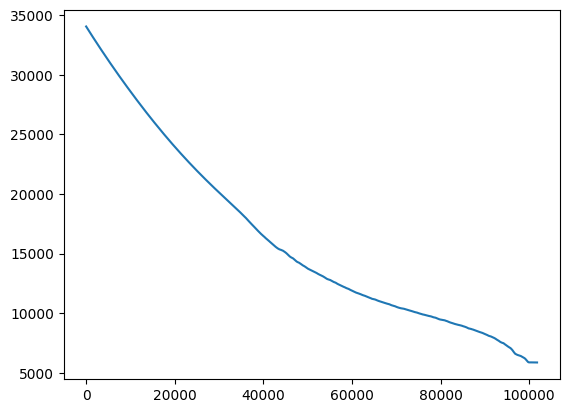

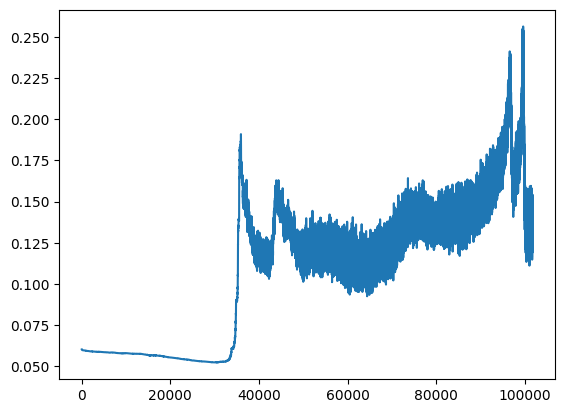

In [ ]:
iter = np.arange(1, N_ITER+1, 1)

plt.figure()
plt.plot(iter, e_tot_tab)
plt.show()

plt.figure()
plt.plot(iter, gradE_tab)
plt.show()
